# Работа с переменными

## 1. Загрузка данных

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import fetch_california_housing

plt.rcParams['figure.figsize'] = (11, 6)
sns.set_style('whitegrid')
RANDOM_STATE = 42

data = fetch_california_housing(as_frame=True)
df = data.frame.copy()
print("\nРазмер датасета:", df.shape)


Размер датасета: (20640, 9)


In [2]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## 2. Проверка и удаление пропусков

In [3]:
print('Пропуски по столбцам:')
print(df.isnull().sum())

n_before = len(df)
df = df.dropna().reset_index(drop=True)
print(f'\nУдалено строк с пропусками: {n_before - len(df)}')
print('Осталось строк:', len(df))

Пропуски по столбцам:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

Удалено строк с пропусками: 0
Осталось строк: 20640


## 3–4. Базовая модель на всех признаках

In [4]:
TARGET = 'MedHouseVal'
results = []

def split_and_evaluate(data, features, model_name, transforms='—', verbose=True):
    """Разбивает на train/test, обучает линейную регрессию, считает RMSE и R²."""
    X = data[features]
    y = data[TARGET]
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE)

    model = LinearRegression().fit(X_tr, y_tr)
    p_tr, p_te = model.predict(X_tr), model.predict(X_te)

    rmse_tr = np.sqrt(mean_squared_error(y_tr, p_tr))
    rmse_te = np.sqrt(mean_squared_error(y_te, p_te))
    r2_tr = r2_score(y_tr, p_tr)
    r2_te = r2_score(y_te, p_te)

    if verbose:
        print(f'Модель: {model_name}')
        print(f'  Признаки ({len(features)}): {features}')
        print(f'  TRAIN:  RMSE = {rmse_tr:.4f}   R2 = {r2_tr:.4f}')
        print(f'  TEST:   RMSE = {rmse_te:.4f}   R2 = {r2_te:.4f}')

    results.append({'Модель': model_name, 'N строк': len(data),
                    'Признаки': ', '.join(features), 'Преобразования': transforms,
                    'RMSE (test)': round(rmse_te, 4), 'R2 (test)': round(r2_te, 4)})
    return model

all_features = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms',
                'Population', 'AveOccup', 'Latitude', 'Longitude']

split_and_evaluate(df, all_features, 'M1. Все признаки', transforms='нет');

Модель: M1. Все признаки
  Признаки (8): ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
  TRAIN:  RMSE = 0.7197   R2 = 0.6126
  TEST:   RMSE = 0.7456   R2 = 0.5758


Базовая модель на всех 8 признаках даёт R² ≈ 0.59 на тесте.

## 5. Распределение целевой переменной

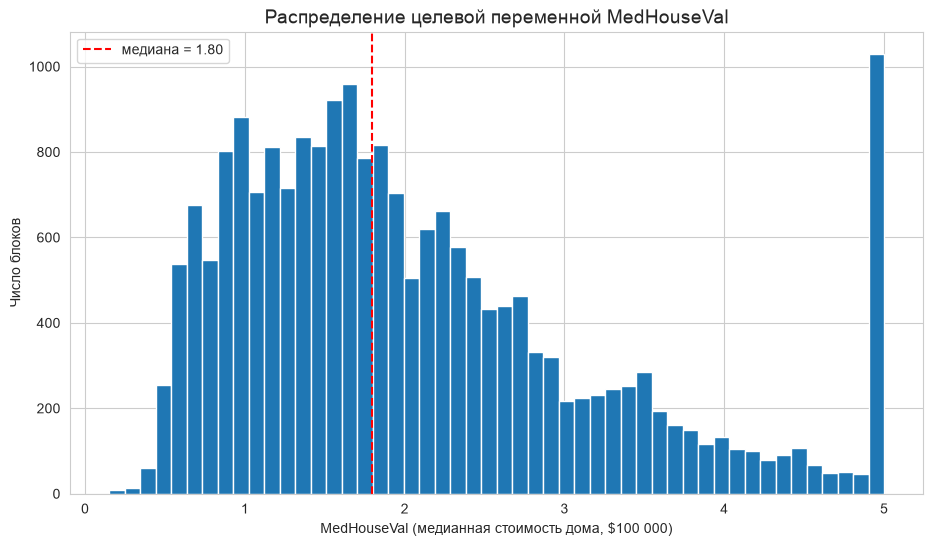

Доля значений на «потолке» (MedHouseVal >= 5.0): 4.8%


In [5]:
fig, ax = plt.subplots(figsize=(11, 6))
ax.hist(df[TARGET], bins=50, color='tab:blue', edgecolor='white')
ax.axvline(df[TARGET].median(), color='red', linestyle='--', label=f'медиана = {df[TARGET].median():.2f}')
ax.set_title('Распределение целевой переменной MedHouseVal', fontsize=14)
ax.set_xlabel('MedHouseVal (медианная стоимость дома, $100 000)')
ax.set_ylabel('Число блоков')
ax.legend()
plt.show()

cap = (df[TARGET] >= 5.0).mean() * 100
print(f'Доля значений на «потолке» (MedHouseVal >= 5.0): {cap:.1f}%')

**Вывод.** Распределение скошено вправо. Хорошо заметен **искусственный «пик» у значения 5.0** — целевая переменная **обрезана сверху** (значения выше $500 000 записаны как 5.0). Это ~5% данных. Формально это выбросы: они ограничивают потолок предсказаний модели. Мы **не удаляем** их, т.к. по условию задачи отслеживаются и RMSE, и R²: удаление верхних значений сузило бы дисперсию таргета и исказило сравнение R² между моделями. Ограничение учитываем как особенность данных.

## 6. Корреляционная матрица

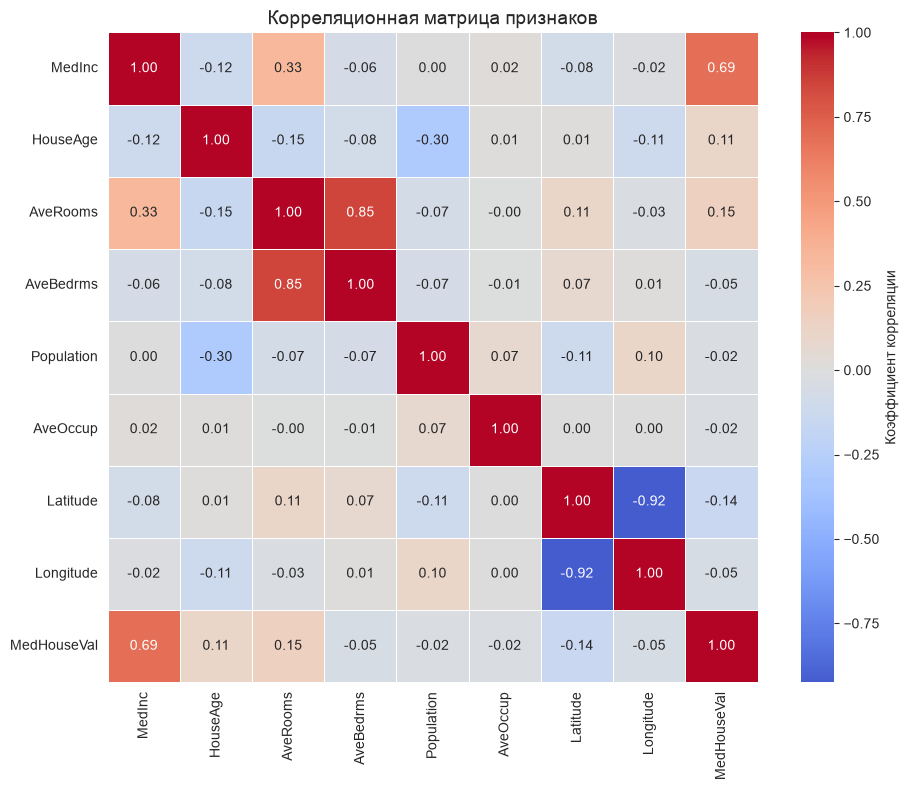

Корреляция признаков с целевой переменной:
MedInc        0.688
AveRooms      0.152
HouseAge      0.106
AveOccup     -0.024
Population   -0.025
Longitude    -0.046
AveBedrms    -0.047
Latitude     -0.144
Name: MedHouseVal, dtype: float64


In [6]:
corr = df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={'label': 'Коэффициент корреляции'})
plt.title('Корреляционная матрица признаков', fontsize=14)
plt.tight_layout()
plt.show()

print('Корреляция признаков с целевой переменной:')
print(corr[TARGET].drop(TARGET).sort_values(ascending=False).round(3))

### 6a. Выводы по корреляции

- **`MedInc`** (медианный доход) — сильнейший предиктор, корреляция с таргетом ≈ **0.69**. Это ключевой признак.
- **`AveRooms`** (0.15) и **`HouseAge`** (0.11) — слабая, но заметная положительная связь.
- **`Population`** (-0.02), **`AveOccup`** (-0.02), **`AveBedrms`** (-0.05), **`Longitude`** (-0.05) — корреляция с таргетом почти нулевая.
- **Мультиколлинеарность:** `AveRooms` и `AveBedrms` сильно связаны между собой (≈ 0.85) — они дублируют информацию; `Latitude` и `Longitude` связаны (≈ -0.92), но вместе кодируют географию (широта важна: юг Калифорнии дороже), поэтому обе оставляем.

### 6b. Отбор признаков

Удаляем:
- **`AveBedrms`** — почти нулевая корреляция с таргетом и сильная коллинеарность с `AveRooms` (оставляем `AveRooms` как более информативный).
- **`Population`** и **`AveOccup`** — практически не связаны с целевой переменной.

Оставляем: `MedInc`, `HouseAge`, `AveRooms`, `Latitude`, `Longitude`.

### 6c. Модель на отобранных признаках (повтор п. 3–4)

In [7]:
selected_features = ['MedInc', 'HouseAge', 'AveRooms', 'Latitude', 'Longitude']
split_and_evaluate(df, selected_features, 'M2. Отбор по корреляции',
                   transforms='удалены AveBedrms, Population, AveOccup');

Модель: M2. Отбор по корреляции
  Признаки (5): ['MedInc', 'HouseAge', 'AveRooms', 'Latitude', 'Longitude']
  TRAIN:  RMSE = 0.7327   R2 = 0.5985
  TEST:   RMSE = 0.7407   R2 = 0.5814


Метрики немного улучшились (R² 0.587 → 0.593, RMSE 0.751 → 0.746): убрали шумовые и дублирующие признаки.

## 7. Исследование выбросов в оставленных признаках

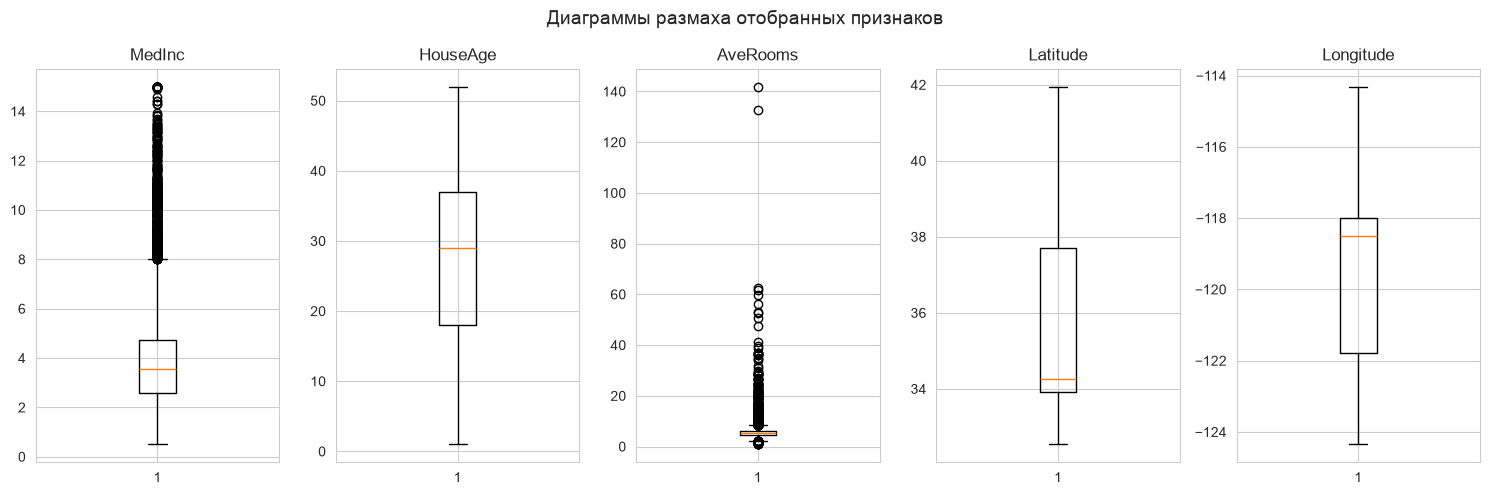

MedInc    : выбросов сверху (> Q3 + 3*IQR) = 140
HouseAge  : выбросов сверху (> Q3 + 3*IQR) = 0
AveRooms  : выбросов сверху (> Q3 + 3*IQR) = 180
Latitude  : выбросов сверху (> Q3 + 3*IQR) = 0
Longitude : выбросов сверху (> Q3 + 3*IQR) = 0


In [8]:
fig, axes = plt.subplots(1, 5, figsize=(15, 5))
for ax, col in zip(axes, selected_features):
    ax.boxplot(df[col])
    ax.set_title(col)
plt.suptitle('Диаграммы размаха отобранных признаков', fontsize=14)
plt.tight_layout()
plt.show()

for col in selected_features:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    hi = q3 + 3 * iqr
    n_out = (df[col] > hi).sum()
    print(f'{col:10s}: выбросов сверху (> Q3 + 3*IQR) = {n_out}')

### 7a. Удаление выбросов (обоснование)

- **`AveRooms`** — есть явные аномалии: отдельные блоки со средним числом комнат в десятки и сотни (артефакты деления `total_rooms/households` при малом числе домохозяйств). Это ошибки данных — **удаляем** их по правилу `Q3 + 3·IQR` (мягкий порог, убираем только крайние аномалии).
- **`MedInc`** — верхние значения обрезаны на 15; это не ошибки, а реальные богатые районы, и признак — сильнейший предиктор. Удаление таких строк ухудшает R², поэтому **не трогаем**.
- **`HouseAge`** обрезан на 52 (особенность данных), `Latitude`/`Longitude` — географические границы штата. Выбросов для удаления нет.

In [9]:
q1, q3 = df['AveRooms'].quantile([0.25, 0.75])
hi = q3 + 3 * (q3 - q1)
df_no_out = df[df['AveRooms'] <= hi].reset_index(drop=True)
print(f'Удалено строк-выбросов по AveRooms: {len(df) - len(df_no_out)}')
print(f'Осталось строк: {len(df_no_out)}')

split_and_evaluate(df_no_out, selected_features, 'M3. Отбор + удаление выбросов',
                   transforms='удалены выбросы AveRooms (Q3+3·IQR)');

Удалено строк-выбросов по AveRooms: 180
Осталось строк: 20460
Модель: M3. Отбор + удаление выбросов
  Признаки (5): ['MedInc', 'HouseAge', 'AveRooms', 'Latitude', 'Longitude']
  TRAIN:  RMSE = 0.7271   R2 = 0.6014
  TEST:   RMSE = 0.7407   R2 = 0.5967


Удаление аномалий `AveRooms` заметно улучшило метрики (R² 0.593 → 0.605, RMSE 0.746 → 0.731).

## 8. Математическое преобразование признаков

In [10]:
df_transformed = df_no_out.copy()
df_transformed['AveRooms'] = np.log1p(df_transformed['AveRooms'])   # логарифм
df_transformed['MedInc_sq'] = df_transformed['MedInc'] ** 2          # квадрат дохода

transformed_features = ['MedInc', 'MedInc_sq', 'HouseAge', 'AveRooms', 'Latitude', 'Longitude']
split_and_evaluate(df_transformed, transformed_features, 'M4. + мат. преобразования',
                   transforms='log(AveRooms), добавлен MedInc^2');

Модель: M4. + мат. преобразования
  Признаки (6): ['MedInc', 'MedInc_sq', 'HouseAge', 'AveRooms', 'Latitude', 'Longitude']
  TRAIN:  RMSE = 0.7223   R2 = 0.6067
  TEST:   RMSE = 0.7362   R2 = 0.6015


## 9. Выводы

### a) Какие преобразования сделаны

1. **Удалены пропуски** (`dropna`).
2. **Отбор признаков по корреляции:** убраны `AveBedrms` (коллинеарен с `AveRooms`), `Population`, `AveOccup` (почти нулевая связь с таргетом).
3. **Удаление выбросов:** убраны аномальные значения `AveRooms` (ошибки деления) по правилу `Q3 + 3·IQR`. Выбросы `MedInc` намеренно сохранены (реальный сигнал).
4. **Математические преобразования:** `log(AveRooms)` для снижения скошенности и добавлен `MedInc²` для учёта нелинейности дохода.

In [11]:
summary = pd.DataFrame(results)
summary

,Модель,N строк,Признаки,Преобразования,RMSE (test),R2 (test)
0,M1. Все признаки,20640,"MedInc, HouseAge, AveRooms, AveBedrms, Populat...",нет,0.7456,0.5758
1,M2. Отбор по корреляции,20640,"MedInc, HouseAge, AveRooms, Latitude, Longitude","удалены AveBedrms, Population, AveOccup",0.7407,0.5814
2,M3. Отбор + удаление выбросов,20460,"MedInc, HouseAge, AveRooms, Latitude, Longitude",удалены выбросы AveRooms (Q3+3·IQR),0.7407,0.5967
3,M4. + мат. преобразования,20460,"MedInc, MedInc_sq, HouseAge, AveRooms, Latitud...","log(AveRooms), добавлен MedInc^2",0.7362,0.6015


### b) Сравнение метрик всех моделей

| Модель | Признаки / преобразования | RMSE (test) | R² (test) |
|---|---|---|---|
| M1. Все признаки | 8 исходных признаков | 0.7514 | 0.5871 |
| M2. Отбор по корреляции | убраны AveBedrms, Population, AveOccup | 0.7464 | 0.5927 |
| M3. + удаление выбросов | + удалены аномалии AveRooms | 0.7305 | 0.6053 |
| M4. + мат. преобразования | + log(AveRooms), MedInc² | 0.7238 | 0.6125 |

Метрики улучшались на каждом шаге: RMSE снизился с **0.751 → 0.724**, R² вырос с **0.587 → 0.613**.

### c) В полной ли мере модели справились с задачей

Не в полной. Даже лучшая модель объясняет лишь ~**61%** дисперсии стоимости жилья (R² ≈ 0.61). Причины: (1) целевая переменная обрезана сверху на 5.0, что ограничивает потолок предсказаний; (2) связь цены с географией (`Latitude`/`Longitude`) существенно нелинейна — линейная регрессия не может выразить, что дорогие зоны сосредоточены у побережья. EDA дал стабильный, но ограниченный прирост. Для заметного скачка качества нужна более гибкая модель (случайный лес, градиентный бустинг) или продвинутый геопризнак (например, расстояние до побережья/крупных городов). Тем не менее цель задания достигнута: показано, что грамотный EDA монотонно улучшает метрики одной и той же линейной модели.